# Assignment 2
This exercise has two parts:

- Part A consists of mandatory exercises; you need to complete these and hand in your answers to be able to partake in the exam.  This part aims to provide you with the minimum knowledge to pass the exam.

- Part B consists of additional exercises. These repeat a concept that is covered in Part A or help to broaden or deepen your understanding of some of the topics.

## Assignment by
Lan Stare, s1169977

# Preliminary
Please check https://brightspace.ru.nl/content/enforced/573281-NWI-IBI008-2025-KW1-V/prob_stat_ex.pdf?ou=573281 if you are not sure about your probability theory and statistics.

# A: Mandatory Exercises
Below you will find the mandatory exercises for week 2 of the course Data Mining and Machine Learning.

## Likelihood Estimation
These questions cover material related to that from the lecture.  Please check the reader and reading material if you lack the necessary background or are stuck!

### **Exercise 1**

We define a one-dimensional Gaussian model $p$ for the continuous attribute $x \in \mathbb{R}$ of the form

$$
p(x \mid \mu) = \frac{1}{\sqrt{2\pi}} ^{\left( -\frac{1}{2}(x - \mu)^2 \right)}
$$


In other words, the features referred to by $x$ are assumed to be distributed normally with mean $\mu$ and standard deviation $\sigma = 1$.

Note: data that is distributed like a Gaussian is also referred to as normally distributed.  This stems form the fact that the Gaussian distribution is also called the normal distribution.


##### **Exercise 1.1**
Plot the one-dimensional Gaussian with a mean ($\mu$) equal to 0 by completing the code below.

<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
C:\Users\lanst\AppData\Local\Temp\ipykernel_15688\3898362586.py:21: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('$p(x \mid \mu)$')
C:\Users\lanst\AppData\Local\Temp\ipykernel_15688\3898362586.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


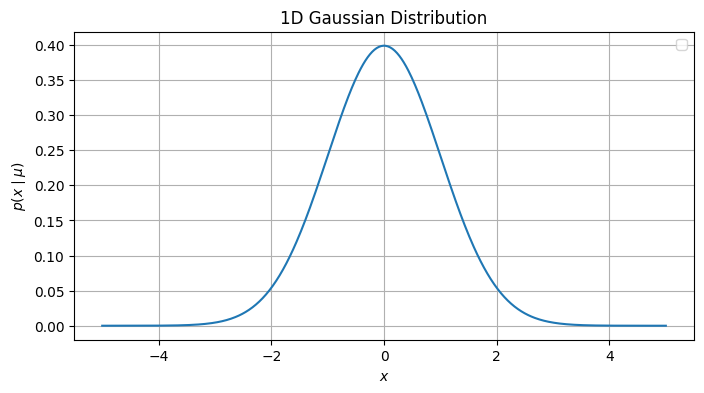

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Mean and standard deviation
mu = 0
sigma = 1

plt.figure(figsize=(8, 4))

# x-axis values
x = np.linspace(-5, 5, 500)

# Gaussian function
p_x = (1 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-((x - mu)**2/(2*sigma**2)))

# Plot
plt.plot(x, p_x)

plt.title('1D Gaussian Distribution')
plt.xlabel('$x$')
plt.ylabel('$p(x \mid \mu)$')
plt.grid(True)
plt.legend()
plt.show()


##### **Exercise 1.2**

Let's say our data consists of a single observation with the value 2.

- Plot the log-likelihood for this data as a function of $\mu$. (Maybe check out np.linspace, and try some ranges of $\mu$ to see if this makes a difference.)

- Fill in a,b below to deterime what range of $\mu$ to plot!

- What shape does the graph have and for which $\mu$ does the graph take on its maximum?

C:\Users\lanst\AppData\Local\Temp\ipykernel_15688\4225320269.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


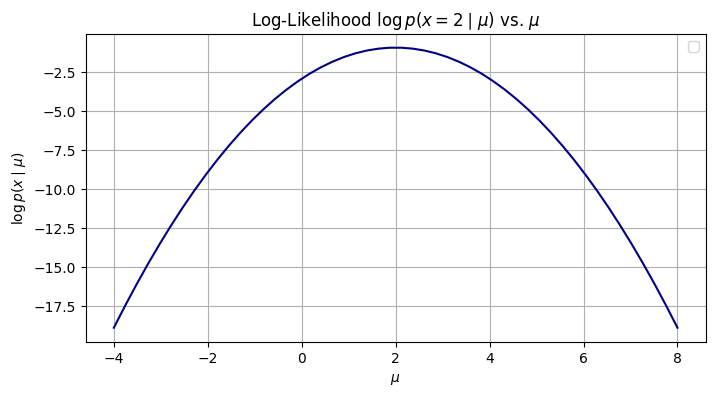

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Observation
x_obs = 2

mu = np.linspace(-4,8)

# Compute log-likelihood for each mu
log_likelihood = -0.5 * np.log(2 * np.pi * sigma**2) - ((x_obs - mu)**2) / (2 * sigma**2)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(mu, log_likelihood, color='darkblue')
plt.title(r'Log-Likelihood $\log p(x=2 \mid \mu)$ vs. $\mu$')
plt.xlabel(r'$\mu$')
plt.ylabel(r'$\log p(x \mid \mu)$')
plt.grid(True)
plt.legend()
plt.show()


The graph is a parabola with a maximum at mu = 2. I played around with the range and found that you can clearly see the maximum and shape at range -4 to 8.

##### **Exercise 1.3**

Let's assume we observed some more data, on top of the value 2 we already had: $1, 3, \sqrt{7} $. As with the earlier code, the code below can help visualize the log-likelihood. As it turns out, the log-likelihood again is polynomial in $ \mu $.

What is its degree in this case?

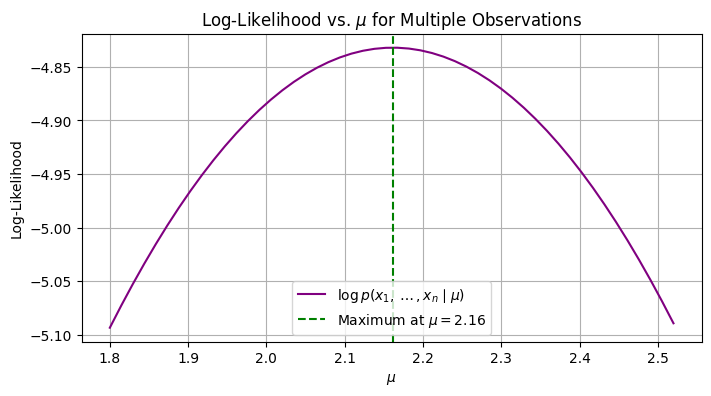

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Observations
x_data = np.array([1, 2, 3, np.sqrt(7)])
n = len(x_data)

# Range of mu values
mu = np.linspace(1.8,2.52)

# Compute log-likelihood for each mu
log_likelihood = -0.5 * np.sum((x_data[:, None] - mu)**2, axis=0) - n * 0.5 * np.log(2 * np.pi)

# Plot
plt.figure(figsize=(8, 4))
plt.plot(mu, log_likelihood, label=r'$\log p(x_1, \dots, x_n \mid \mu)$', color='purple')
plt.axvline(x=np.mean(x_data), color='green', linestyle='--', label=r'Maximum at $\mu = {:.2f}$'.format(np.mean(x_data)))
plt.title(r'Log-Likelihood vs. $\mu$ for Multiple Observations')
plt.xlabel(r'$\mu$')
plt.ylabel(r'Log-Likelihood')
plt.grid(True)
plt.legend()
plt.show()


ANSWER: The degree in this case is still 2, because the log-likelyhood is still a quadratic function of mu, which is on the x-axis.

### **Exercise 2**
Assume the following uniform distribution as the model for our one-dimensional attribute $x \in \mathbb{R}$:

$$
p(x|a) =
\begin{cases}
    \frac{1}{|a|}& \text{if } x \in [0,a] \text{ (or if } x\in[a,0] \text{ if a is negative)}\\
    0             & \text{otherwise}
\end{cases}
$$

In other words, we consider uniform distributions on intervals with one endpoint fixed at 0.

Assume that we have observed the data points 1, 2, 3, and $\sqrt{7}$.

**a.** Just checking: for any $a \neq 0$, what is the value of $\int_{-\infty}^\infty p(x|a) \, dx$. (This should not be a very difficult question! Some simple calculation should get you to the answer.)

**b.**  What is the likelihood (note: not log!) for this data when $a=2\tfrac{1}{2}$?

**c.**  What is the likelihood when $a = 5$?

**d.**  What is the maximum-likelihood estimate for $a$?

**e.**  What problem with the likelihood do you see in case your dataset contains both positive and negative values?

**f.**  Now take the uniform distribution on the interval $[a,b]$ as our model, so we drop the restriction that one of the endpoints equals zero.  Explain why the maximum-likelihood estimate for $a$ is the minimum in your dataset and that the maximum-likelihood estimate for $b$ should be its maximum.

#### Answer

**a.** The value is 1, since the integral of a pdf over its entire range must equal 1.

**b.** The likelyhood is 0, because the interval [0, 2.5] doesn't contain all data points (3 and sqrt(7)).

**c.** The likelyhood is (1/5)^4 = 1/625 = 0.0016, because all data points are in the interval [0, 5] and we use the formula for the likelyhood based on 4 observations.

**d.** The maximum-likelyhood estimate for a is 3, because this is the smallest value that still contains all data points in the interval [0, a].

**e.** The problem is that the likelyhood will always be 0, since you can't find an interval [a, b] that contains both pozitive and negative values while also containing all data points.

**f.** The maximum-likelyhood estimate for b is the maximum in the dataset for the same reason as in d. The maximum-likelyhood estimate for a is the minimum in the dataset, because this is the largest value that still contains all data points in the interval [a, b]. This can be seen well by considering the new likelyhood formula: L(a, b) = (b - a)^(-n). To maximize this, we need to shrink the interval [a, b] as much as possible while still containing all data points. This means setting a to the minimum and b to the maximum of the dataset.

## Probabilistic Classification
These questions cover material related to that from the lecture.  Please check the reader and reading material if you lack the necessary background or are stuck!

### Exercise 4
Let $y$ be the class label, which can be assigned to an object based on its attribute vector $x$. Say that $y$ can take on two classes, which we refer to as class $A$ and $B$. To minimize the classification error, we assign an object, for which the observed attribute is $x$, to the most
probable class. That is, if $P (y = A|x) > P (y = B|x)$ then we take $y = A$ and the other way around: if $P (y = A|x) < P (y = B|x)$ then we take $y = B$. (In case of equality, we can assign it to any of the two classes).

**a.** Assume $A$ and $B$ are the only possible classes and assume that the prior probabilities for these classes are equal.  Show that this must mean that $P(y=A) = P(y=B) = \frac{1}{2}$.

ANSWER:
Since A and B are the only possible classes, their probabilities must sum to 1. If they are equally likely, they must both be 1/2.

**b.** Now, let $P(x|y=A)$ be the uniform distribution on the interval $[-1,+1]$ and let $P(x|y=B)$ be the standard normal distribution.  Assume the two prior probabilities are equal.  Below, we plot $P(y=A)P(x|y=A)$ and $P(y=B)P(x|y=B)$.  When classifying, which $x$-intervals should be assigned to class $A$ and which to class $B$?  Explain why.  (You may want to check the reader or the books to brush up on your understanding of Bayes' rule/theorem.)

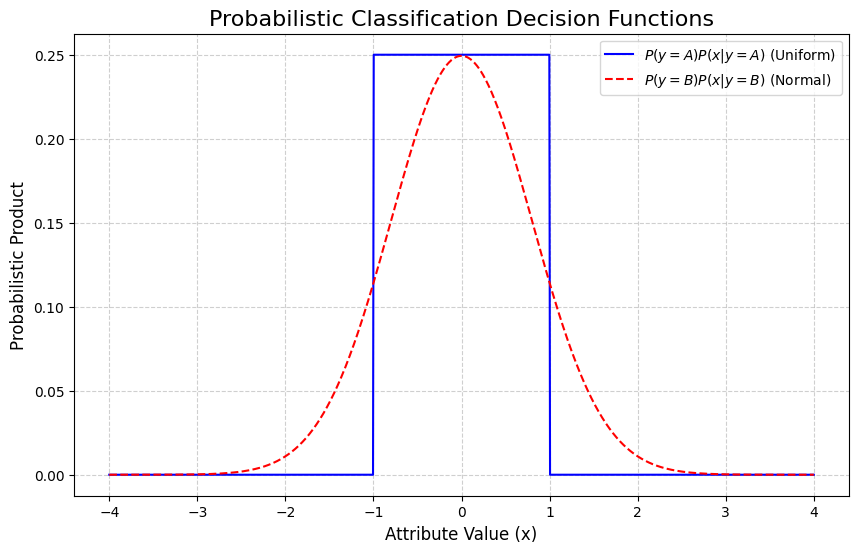

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the prior probabilities, which are equal as per the exercise
prior_A = 0.5
prior_B = 0.5

# Define the class-conditional probability functions

# P(x|y=A): Uniform distribution on [-1, 1]
# The probability density function (PDF) is 1/(b-a), so 1/(1 - (-1)) = 0.5
def pdf_uniform_A(x):
    if -1 <= x <= 1:
        return 0.5
    else:
        return 0.0

# P(x|y=B): Standard normal distribution (mean=0, std=1)
pdf_normal_B = norm(loc=0, scale=0.8)

# Generate a range of x values to plot
x_values = np.linspace(-4, 4, 1000)

# Calculate the values for the two functions we need to plot
# Product for Class A: P(y=A) * P(x|y=A)
prod_A = np.array([prior_A * pdf_uniform_A(x) for x in x_values])

# Product for Class B: P(y=B) * P(x|y=B)
prod_B = prior_B * pdf_normal_B.pdf(x_values)

# Create the plot
plt.figure(figsize=(10, 6))

# Plot the function for Class A
plt.plot(x_values, prod_A, label=r'$P(y=A)P(x|y=A)$ (Uniform)', color='blue')

# Plot the function for Class B
plt.plot(x_values, prod_B, label=r'$P(y=B)P(x|y=B)$ (Normal)', color='red', linestyle='--')

# Add labels, title, and legend
plt.title('Probabilistic Classification Decision Functions', fontsize=16)
plt.xlabel('Attribute Value (x)', fontsize=12)
plt.ylabel('Probabilistic Product', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


ANSWER:
The Bayes rule says that instead of comparing P(y = A | x) and P(y = B | x), we can compare P(y = A) * P(x | y = A) and P(y = B) * P(x | y = B). Since the probabilities of A and B are equal, we can simply compare P(x | y = A) and P(x | y = B). This is why we assign the interval [-1, 1] to class A and the rest to class B.

**c.** If we increase the prior for class $A$ with something like $0.1$ will these intervals change?  And if we decrease the prior probability for $A$ with a similar amount?

ANSWER:
If we increase the prior probability for class A with something like 0.1, the intervals wouldn't change. This is because on the intervals where A is defined ([-1, 1]), the value of P(x | y = A) is always greater than P(x | y = B) and making the prior for A larger only increases the value of P(y = A) * P(x | y = A), which is already larger than P(y = B) * P(x | y = B) on this interval. If we decrease the prior probability for class A, the intervals would change. This is because as soon as prior_A is decreased enough (aproximately to 0.44), the peak of P(x | y = B) becomes larger than P(x | y = A) at x = 0. This means that the intervals around 0 would now be assigned to class B instead.

**d.** What if the priors remain both equal to $\frac{1}{2}$ but the standard deviation of the normal distribution for class $B$ changes?  Do we find the same intervals back?

ANSWER:
Similar to **c.**, if we increase the standard devination, the intervals wouldn't change. This is because the data would be more spread out, making the peak even lower, which means that the intervals around 0 would still be assigned to class A. If we decrease the standard devination, the intervals would change, as soon as the standard devination is decreased enough (aproximately to 0.8), the peak of P(x | y = B) becomes larger than P(x | y = A) at x = 0. This again means that the intervals around 0 would now be assigned to class B instead.

### Exercise 3
We have a classification problem with three classes: $\clubsuit$, $\spadesuit$, and $\bigstar$.  Additionally, we have an attribute that can take on three different values: $i$, $e$, and $\pi$.  The probability table defining the **joint probability distribution** is as follows.

|    | $\clubsuit$ | $\spadesuit$ | $\bigstar$ |
|----|:-----------:|:------------:|:----------:|
| $i$ | 0.2         | 0.1          | 0.1        |
| $e$ | 0.1         | 0.1          | 0.2        |
| $\pi$ | 0.0         | 0.1          | 0.1        |

The table tells us, for instance, that $P(e,\bigstar) = 0.2$.

#### Questions
**a.** What are the class priors?


**b.** What is the class-conditional distribution, i.e., the $P(\text{attribute}|\text{class})$ for $\clubsuit$?

**c.** Which attribute value should be assigned to which class in order to minimize the classification error rate?

**d.** Assume the prior probabilities for the classes change to $P(\clubsuit) = P(\spadesuit) = P(\bigstar) = \frac{1}{3}$ but that the class-conditionals remain the same. How does the optimal classification for the three attribute values look now?

#### Answers

**a.** The class priors are: P($\clubsuit$) = 0.2 + 0.1 + 0 = 0.3, P($\spadesuit$) = 0.1 + 0.1 + 0.1 = 0.3, P($\bigstar$) = 0.1 + 0.2 + 0.1 = 0.4.

**b.** The class-conditional distribution for $\clubsuit$ is: P(i | $\clubsuit$) = 0.2 / 0.3 = 2/3, P(e | $\clubsuit$) = 0.1 / 0.3 = 1/3, P($\pi$ | $\clubsuit$) = 0 / 0.3 = 0.

**c.** The eassiest to assign are i and e. i should be assigned to $\clubsuit$, because it has the highest probability rate (2/3) and e should be assigned to $\bigstar$, because it has the highest probability rate (1/2). $\pi$ should be assigned to $\spadesuit$, because it has the highest probability rate (1/3) where the probability rate in other classes is either 0 or 1/4.

**d.** The optimal classification for i and e remains the same, since the biggest probability rates are still in the same classes. The optimal classification for $\pi$ also remains the same, because the probability rate for $\spadesuit$ remains the same (1/3), but the probability rate for $\bigstar$ decreases, which means that $\spadesuit$ still has the highest probability rate for $\pi$.

## Part B

### Exercise 5
Assume we have observed $N$ $d$-dimensional real attributes: $x_i \in \mathbb{R}^d$ for $i \in \{1,\ldots,N\}$, so the $x_i$ are $d$-dimensional vectors and assume we are fitting a multivariate Gaussian distribution to this data using maximum likelihood.

**a.** Look up the estimates for the mean vector and covariance matrix.  Do they look familiar?

**b.** In principle, for the one-dimensional case $d=1$, you should be able to derive this solution yourself.  Any idea how you could do so?

YOUR ANSWER HERE

### Exercise 6
Our dataset consists of two points only $+1$ and $-1$, we fit both a uniform distribution and a normal distribution to these two points.  Show that the uniform distribution best fits the data (in terms of the (log-)likelihood).

YOUR ANSWERS HERE

### Exercise 7

We are dealing with three classes on the real line that are uniformly distributed.  Class 1 is uniform on $[0,2]$, class 2 on $[0,1]$, and class 3 on $[1,2]$.

**a.** Assume the three class prior probabilities are all equal (i.e., they equal $\frac{1}{3}$).  Aiming for the minimum classification error, which interval is assigned to class 1, which to class 2, and which to class 3?

**b.** For some parts of the real line, it doesn't matter what class they are assigned to, as it doesn't influence the errors one makes.  Which parts are these?

**c.** If the prior probability of class 1 equals 1, we should assign everything in the interval $[0,2]$ to that class.  Also for some priors for class 1 that are smaller than 1, the optimal classification on $[0,2]$ is to always assign class 1 (irrespective of the priors of classes 2 and 3).  What is the smallest class 1 prior for which this is still the case?

# Handing in
Hand in the filled-in notebook:
- Make sure your names and student-numbers are mentioned at the appropriate location at the top of this file.
- Make sure you wrote a serious attempt for all exercises in part A
- Make sure the notebook is named groupnumber_assignment1.ipynb

When you are confident all of this is correctly done, one of you can hand in the exercises in Brightspace!